In [15]:
import numpy as np 
import matplotlib.pyplot as plt

In [ ]:
# activationn fnt foor the perceptron 


def sigmoid(x):
    # Sigmoid squashes values into range (0,1), useful for probabilities
    return 1/(1+np.exp(-x))

def sigmoid_derivative(x):
    # Derivative of sigmoid, assuming x is already sigmoid(x), used in backprop
    ###The derivative tells us how sensitive the output is to changes in the input.
    return x*(1-x)

def relu(x):
    # ReLU outputs zero for negative inputs and passes positive values through
    return np.maximum(0, x)

def relu_derivative(x):
    # Derivative of ReLU: 0 for x<=0, 1 for x>0
    return (x > 0).astype(float)


In [4]:
# loss funtion

def mse_loss(y_true, y_pred):
    return np.mean((y_true - y_pred)**2)

def mse_loss_derivative(y_true, y_pred):
    return (y_pred - y_true)


In [5]:
# XOR dataset
X = np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1]
])

y = np.array([[0], [1], [1], [0]])


 Neural Network Initialization 
 Input: 2 features

 Hidden: 3 neurons

 Output: 1 neuro

W1 =
[[w11, w12, w13],
 [w21, w22, w23]]

 W2 =
[[w1],
 [w2],
 [w3]]

 b1 = np.zeros((1, 3))
[ b1  b2  b3 ]

b2 = np.zeros((1, 1))
[ b ]




In [9]:

np.random.seed(42)

# initialize weights
W1 = np.random.randn(2, 3)     # (input → hidden)
b1 = np.zeros((1, 3))

W2 = np.random.randn(3, 1)     # (hidden → output)
b2 = np.zeros((1, 1))

lr = 0.1  # learning rate



In [10]:
#Forward Propagation
def forward(X):
    # Hidden layer
    z1 = np.dot(X, W1) + b1
    a1 = sigmoid(z1)

    # Output layer
    z2 = np.dot(a1, W2) + b2
    a2 = sigmoid(z2)

    return z1, a1, z2, a2


In [ ]:
#Backpropagation
def backward(X, y, z1, a1, z2, a2):
    global W1, b1, W2, b2
 
 # mse_loss_derivative == How wrong is the output
 # sigmoid_derivative == How sensitive is the neuron output to its input (z2)
    # Output layer error
    dz2 = mse_loss_derivative(y, a2) * sigmoid_derivative(a2)
    dW2 = np.dot(a1.T, dz2)
    db2 = np.sum(dz2, axis=0, keepdims=True)

    # Hidden layer error
    dz1 = np.dot(dz2, W2.T) * sigmoid_derivative(a1)
    dW1 = np.dot(X.T, dz1)
    db1 = np.sum(dz1, axis=0)

    # Gradient descent (updated)
    W2 -= lr * dW2
    b2 -= lr * db2
    W1 -= lr * dW1
    b1 -= lr * db1


In [13]:
#Training Loop
epochs = 5000
losses = []

for i in range(epochs):
    z1, a1, z2, a2 = forward(X)
    backward(X, y, z1, a1, z2, a2)

    loss = mse_loss(y, a2)
    losses.append(loss)

    if i % 500 == 0:
        print(f"Epoch {i}  Loss: {loss:.4f}")


Epoch 0  Loss: 0.3182
Epoch 500  Loss: 0.2324
Epoch 1000  Loss: 0.2057
Epoch 1500  Loss: 0.1750
Epoch 2000  Loss: 0.1419
Epoch 2500  Loss: 0.0992
Epoch 3000  Loss: 0.0587
Epoch 3500  Loss: 0.0329
Epoch 4000  Loss: 0.0201
Epoch 4500  Loss: 0.0136


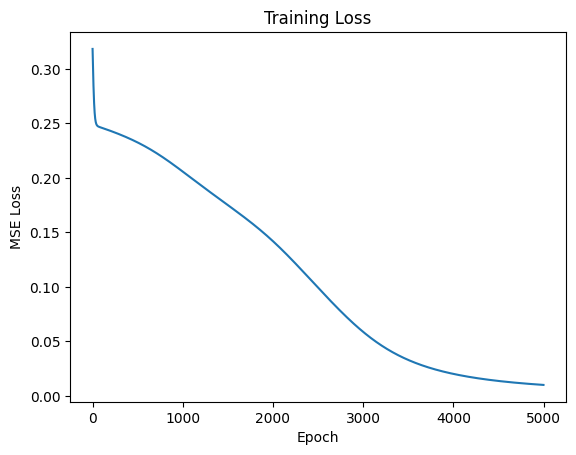

In [16]:
plt.plot(losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.show()


In [17]:
_, _, _, predictions = forward(X)
print("Predictions:")
print(predictions.round(3))


Predictions:
[[0.059]
 [0.905]
 [0.897]
 [0.129]]
